# KMEANS

## Load Data & Cek Informasi Dataset

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load dataset (pastikan file Mall_Customers.csv satu folder sama notebook lo)
df = pd.read_csv("../Mall_Customers.csv")

# Lihat 5 baris pertama data
display(df.head())

# Cek info dasar dataset
df.info()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


## Pilih Fitur & Elbow Method (Cari k Terbaik)

d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

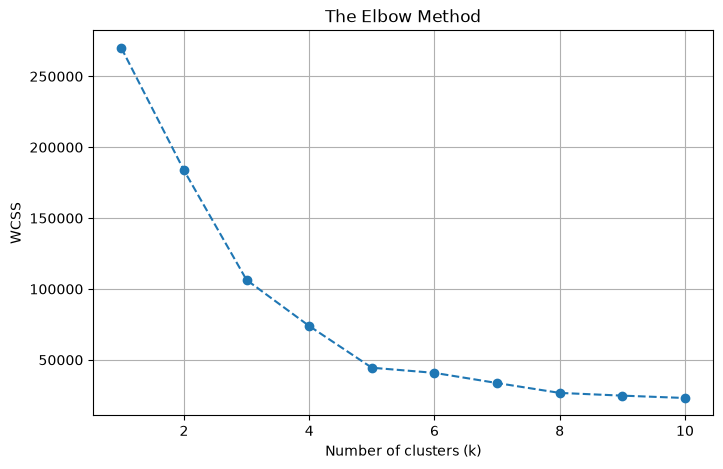

In [3]:
from sklearn.cluster import KMeans

# Memilih fitur: Annual Income dan Spending Score
X = df.iloc[:, [3, 4]].values

# Menghitung WCSS (Within-Cluster Sum of Square) untuk berbagai nilai k (1 sampai 10)
wcss = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o", linestyle="--")
plt.title("The Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

## Implementasi Model K-Means ($k = 5$) & Visualisasi Klaster

d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


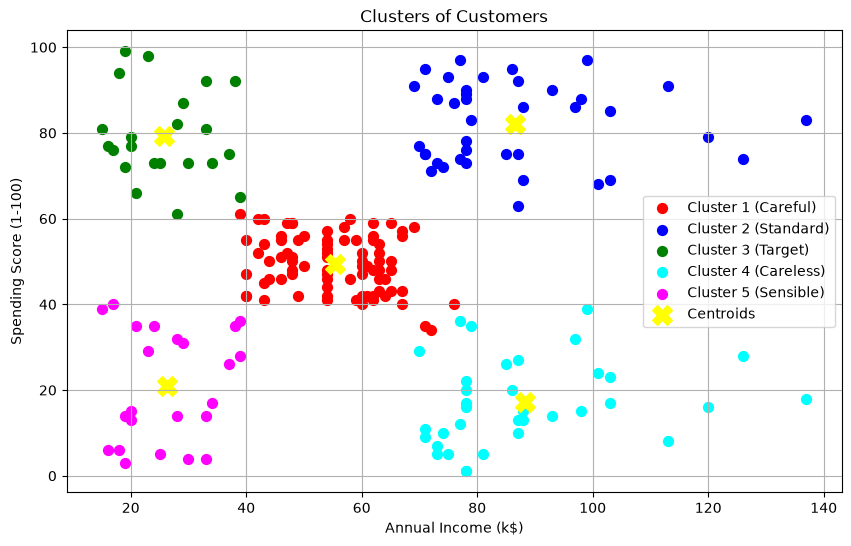

In [4]:
# Membuat model K-Means dengan k = 5
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Visualisasi Hasil Klaster
plt.figure(figsize=(10, 6))
plt.scatter(
    X[y_kmeans == 0, 0],
    X[y_kmeans == 0, 1],
    s=50,
    c="red",
    label="Cluster 1 (Careful)",
)
plt.scatter(
    X[y_kmeans == 1, 0],
    X[y_kmeans == 1, 1],
    s=50,
    c="blue",
    label="Cluster 2 (Standard)",
)
plt.scatter(
    X[y_kmeans == 2, 0],
    X[y_kmeans == 2, 1],
    s=50,
    c="green",
    label="Cluster 3 (Target)",
)
plt.scatter(
    X[y_kmeans == 3, 0],
    X[y_kmeans == 3, 1],
    s=50,
    c="cyan",
    label="Cluster 4 (Careless)",
)
plt.scatter(
    X[y_kmeans == 4, 0],
    X[y_kmeans == 4, 1],
    s=50,
    c="magenta",
    label="Cluster 5 (Sensible)",
)

# Plot Centroid
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c="yellow",
    marker="X",
    label="Centroids",
)

plt.title("Clusters of Customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()

# DBSCAN

## Pembuatan Dataset make_moons & Normalisasi

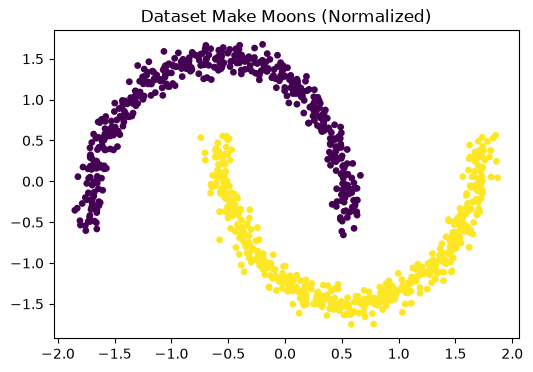

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# 1. Buat dataset make_moons (1000 sampel, noise=0.05)
X, labels_true = make_moons(n_samples=1000, noise=0.05, random_state=42)

# Normalisasi data
X = StandardScaler().fit_transform(X)

# Visualisasi sekilas data asli
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=labels_true, cmap="viridis", s=15)
plt.title("Dataset Make Moons (Normalized)")
plt.show()

## Jalankan DBSCAN & Hitung Cluster/Noise

In [6]:
from sklearn.cluster import DBSCAN
from sklearn import metrics

# 2. Jalankan DBSCAN dengan eps=0.2 dan min_samples=5
db = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels = db.labels_

# Hitung jumlah klaster (mengabaikan noise -1)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Estimasi jumlah klaster: {n_clusters_}")
print(f"Banyaknya titik noise: {n_noise_}")

Estimasi jumlah klaster: 2
Banyaknya titik noise: 0


## Evaluasi Metrik Kualitas Klasterisasi

In [7]:
# 3. Evaluasi dengan berbagai metrik
print(f"Homogeneity         : {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness        : {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure           : {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index : {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(f"Adjusted Mutual Info: {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")
# Silhouette score hanya bisa dihitung jika klaster > 1 dan ada noise/tidak semua jadi 1 klaster
if n_clusters_ > 1:
    print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")
else:
    print("Silhouette Coefficient: Tidak dapat dihitung (klaster <= 1)")

Homogeneity         : 1.000
Completeness        : 1.000
V-measure           : 1.000
Adjusted Rand Index : 1.000
Adjusted Mutual Info: 1.000
Silhouette Coefficient: 0.391


## Visualisasi Hasil DBSCAN

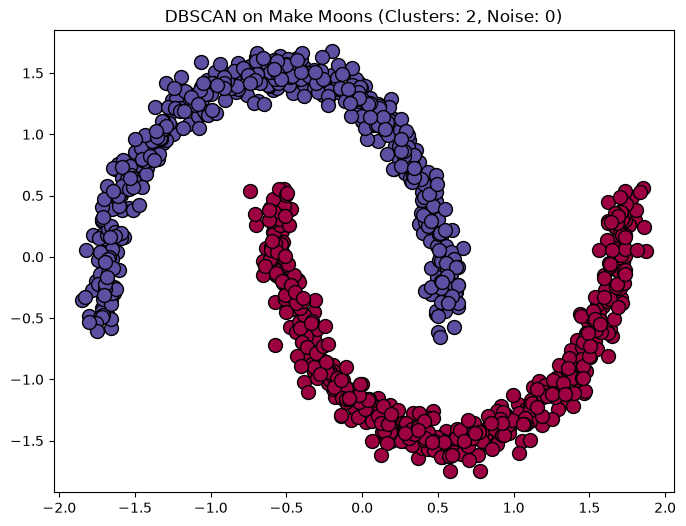

In [9]:
# 4. Visualisasi hasil DBSCAN (core sample = besar, non-core = kecil, noise = hitam)
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Hitam untuk noise

    class_member_mask = (labels == k)

    # Core samples (titik besar)
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0], xy[:, 1], "o",
        markerfacecolor=tuple(col), markeredgecolor="k", markersize=10
    )

    # Non-core samples (titik kecil)
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0], xy[:, 1], "o",
        markerfacecolor=tuple(col), markeredgecolor="k", markersize=4
    )

plt.title(f"DBSCAN on Make Moons (Clusters: {n_clusters_}, Noise: {n_noise_})")
plt.show()

## Eksperimen Parameter (eps dan min_samples)

In [10]:
# 5. Eksperimen berbagai nilai eps dan min_samples
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

results = []

for e in eps_values:
    for ms in min_samples_values:
        db_exp = DBSCAN(eps=e, min_samples=ms).fit(X)
        lbls = db_exp.labels_
        
        n_clust = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_noi = list(lbls).count(-1)
        
        # Hitung ARI sebagai perbandingan kualitas
        ari = metrics.adjusted_rand_score(labels_true, lbls)
        
        results.append({
            'eps': e,
            'min_samples': ms,
            'Clusters': n_clust,
            'Noise_Points': n_noi,
            'ARI': round(ari, 3)
        })

import pandas as pd
df_results = pd.DataFrame(results)
display(df_results)

,eps,min_samples,Clusters,Noise_Points,ARI
0,0.05,3,69,186,0.030
1,0.05,10,3,970,0.002
2,0.05,20,0,1000,0.000
3,0.10,3,2,14,0.972
4,0.10,10,7,57,0.523
5,0.10,20,6,850,0.017
6,0.30,3,2,0,1.000
7,0.30,10,2,0,1.000
8,0.30,20,2,0,1.000
9,0.50,3,2,0,1.000
